# Connectivity Analysis 

Computed from the .npy Matrix Files

In [1]:
# .npy files were generated from the 400 x 400 subject matricies --> then collapses them to the main network mean matrix for analysis

In [3]:
#imports
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker
from itertools import groupby
from pycirclize import Circos


In [ ]:
# change this to your own path where the data is stored
dataset_root = Path("/Users/gaithtry/Downloads/matrix_data/")

writable_cache = '/tmp/nilearn_cache'
if not os.path.exists(writable_cache):
    os.makedirs(writable_cache)

atlas_dataset = datasets.fetch_atlas_schaefer_2018(
    data_dir=dataset_root, n_rois=400, yeo_networks=7
)
atlas_labels = atlas_dataset.labels[1:]

network_assignments = [
    label.decode('utf-8').split('_')[2] if isinstance(label, bytes)
    else label.split('_')[2]
    for label in atlas_labels
]
sort_idx = np.argsort(network_assignments)
print("Network assignments ready:", len(network_assignments), "ROIs")


[fetch_atlas_schaefer_2018] Dataset found in /Users/gaithtry/Downloads/matrix_data/schaefer_2018

Network assignments ready: 400 ROIs


In [7]:
def plot_networks(matrix, ax, vmin=-0.8, vmax=0.8, cmap="RdBu_r"):
    ordered_matrix = matrix[sort_idx, :][:, sort_idx]
    ordered_labels = [network_assignments[i] for i in sort_idx]

    unique_networks = []
    network_sizes = []
    for k, g in groupby(ordered_labels):
        unique_networks.append(k)
        network_sizes.append(sum(1 for _ in list(g)))

    boundaries = np.insert(np.cumsum(network_sizes), 0, 0)
    tick_positions = [(boundaries[i] + boundaries[i+1]) / 2 for i in range(len(boundaries) - 1)]

    display = plotting.plot_matrix(
        ordered_matrix,
        colorbar=True,
        reorder=False,
        axes=ax,
        vmin=vmin, vmax=vmax,
        cmap=cmap,
    )

    colors = plt.cm.Set2(np.linspace(0, 1, len(network_sizes)))
    for i in range(1, len(boundaries) - 1):
        ax.axvline(boundaries[i] - 0.5, color="black", linewidth=0.5, alpha=0.9)
        ax.axhline(boundaries[i] - 0.5, color="black", linewidth=0.5, alpha=0.9)

    bar_width = 15
    matrix_size = ordered_matrix.shape[0]

    for i in range(len(boundaries) - 1):
        start, end = boundaries[i], boundaries[i+1]
        current_color = colors[i]
        ax.axhspan(start - 0.5, end - 0.5, xmin=-bar_width/matrix_size, xmax=0,
                   color=current_color, clip_on=False, zorder=3)
        ax.axvspan(start - 0.5, end - 0.5, ymin=-bar_width/matrix_size, ymax=0,
                   color=current_color, clip_on=False, zorder=3)

    ax.tick_params(axis='both', which='both', length=18, pad=10, direction='out')
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(unique_networks, rotation=90, fontsize=10)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(unique_networks, fontsize=10)


In [9]:
# building 7×7 network-mean DataFrame from a 400×400 matrix
def build_network_matrix(matrix):
    ordered_matrix = matrix[sort_idx, :][:, sort_idx]
    ordered_labels = [network_assignments[i] for i in sort_idx]

    unique_networks, network_sizes = [], []
    for k, g in groupby(ordered_labels):
        unique_networks.append(k)
        network_sizes.append(sum(1 for _ in g))

    boundaries = np.insert(np.cumsum(network_sizes), 0, 0)
    n = len(unique_networks)
    network_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            block = ordered_matrix[boundaries[i]:boundaries[i+1],
                                   boundaries[j]:boundaries[j+1]]
            network_matrix[i, j] = np.mean(block)

    return pd.DataFrame(network_matrix, index=unique_networks, columns=unique_networks)


# 7×7 matrix plot
def plot_7x7_heatmap(network_df, ax, title="", vmin=-0.8, vmax=0.8):
    network_matrix = network_df.values
    unique_networks = list(network_df.index)
    n = len(unique_networks)

    display = plotting.plot_matrix(
        network_matrix,
        colorbar=True,
        reorder=False,
        axes=ax,
        vmin=vmin, vmax=vmax,
    )

    colors = plt.cm.Set2(np.linspace(0, 1, n))
    bar_width = 0.2

    for i in range(1, n):
        ax.axvline(i - 0.5, color="black", linewidth=0.5, alpha=0.9)
        ax.axhline(i - 0.5, color="black", linewidth=0.5, alpha=0.9)

    for i in range(n):
        start, end = i - 0.5, i + 0.5
        color = colors[i]
        ax.axhspan(start, end, xmin=-bar_width/n, xmax=0,
                   color=color, clip_on=False, zorder=3)
        ax.axvspan(start, end, ymin=-bar_width/n, ymax=0,
                   color=color, clip_on=False, zorder=3)

    ax.tick_params(axis='both', which='both', length=18, pad=10, direction='out')
    ax.set_xticks(range(n))
    ax.set_xticklabels(unique_networks, rotation=90, fontsize=10)
    ax.set_yticks(range(n))
    ax.set_yticklabels(unique_networks, fontsize=10)
    ax.set_title(title, fontsize=11, pad=12, fontweight='bold')


# chord diagram based on the 7 x 7 matrix
def plot_chord_diagram(network_df, ax, title="", tmp_png="_tmp_chord.png"):
    chord_df = network_df.copy().abs()   # pycirclize needs non-negative widths
    circos = Circos.chord_diagram(
        chord_df,
        space=3,
        cmap="tab10",
        label_kws=dict(size=12),
        link_kws=dict(ec="black", lw=0.5),
    )
    fig_chord = circos.plotfig()
    fig_chord.savefig(tmp_png, dpi=80, bbox_inches="tight")
    plt.close(fig_chord)

    img = plt.imread(tmp_png)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=11, pad=10, fontweight='bold')


In [11]:
#loading the .npy files
NPY_DIR = Path("/Users/gaithtry/Downloads/matrix_data/")

npy_files = sorted(NPY_DIR.glob("*.npy"))
print(f"Found {len(npy_files)} .npy file(s):\n")

npy_data = {}   # filename_stem -> ndarray (always 3-D: N x 400 x 400)
for fp in npy_files:
    arr = np.load(fp)
    if arr.ndim == 2:          # single matrix saved as (400, 400)
        arr = arr[np.newaxis]  # wrap to (1, 400, 400)
    elif arr.ndim != 3:
        print(f"  WARNING: {fp.name} has unexpected shape {arr.shape}, skipping.")
        continue
    npy_data[fp.stem] = arr
    print(f"  {fp.name}  →  {arr.shape}  ({arr.shape[0]} matrix/matrices)")


Found 4 .npy file(s):

  sleep_matrices_as_given.npy  →  (26, 400, 400)  (26 matrix/matrices)
  sleep_matrices_global_regression.npy  →  (26, 400, 400)  (26 matrix/matrices)
  wake_matrices_as_given.npy  →  (26, 400, 400)  (26 matrix/matrices)
  wake_matrices_global_regression.npy  →  (26, 400, 400)  (26 matrix/matrices)


In [13]:
file_names   = list(npy_data.keys())
mean_matrices = {}   # stem -> averaged (400, 400) matrix

for stem, stack in npy_data.items():
    mean_matrices[stem] = np.mean(stack, axis=0)
    print(f"{stem}: averaged {stack.shape[0]} matrices  →  {mean_matrices[stem].shape}")

sleep_matrices_as_given: averaged 26 matrices  →  (400, 400)
sleep_matrices_global_regression: averaged 26 matrices  →  (400, 400)
wake_matrices_as_given: averaged 26 matrices  →  (400, 400)
wake_matrices_global_regression: averaged 26 matrices  →  (400, 400)


In [ ]:
all_matrices = {**mean_matrices}
#all_matrices = {**mean_matrices, **diff_matrices}

# vmin/vmax: difference matrices get a tighter range automatically
def _vrange(name):
    return (-0.3, 0.3) if "minus" in name.lower() else (-0.8, 0.8)

for stem, mat in all_matrices.items():
    vmin, vmax = _vrange(stem)

    # 7×7 DataFrame
    network_df = build_network_matrix(mat)
    print(f"\n{'='*60}")
    print(f"7×7 Network Matrix — {stem}")
    print(network_df.round(3).to_string())

    # diagrams side by side
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    plot_7x7_heatmap(network_df, axes[0],
                     title=f"{stem} — 7×7 Heatmap", vmin=vmin, vmax=vmax)
    plot_chord_diagram(network_df, axes[1],
                       title=f"{stem} — Chord Diagram",
                       tmp_png=f"_tmp_chord_{stem}.png")

    fig.suptitle(stem, fontsize=14, fontweight='bold')
    plt.tight_layout()
    out_pdf = f"connectivity_{stem}.pdf"
    plt.savefig(out_pdf, dpi=80, bbox_inches="tight")
    print(f"Saved: {out_pdf}")
    plt.show()


Saved: combined_connectivity_summary.pdf


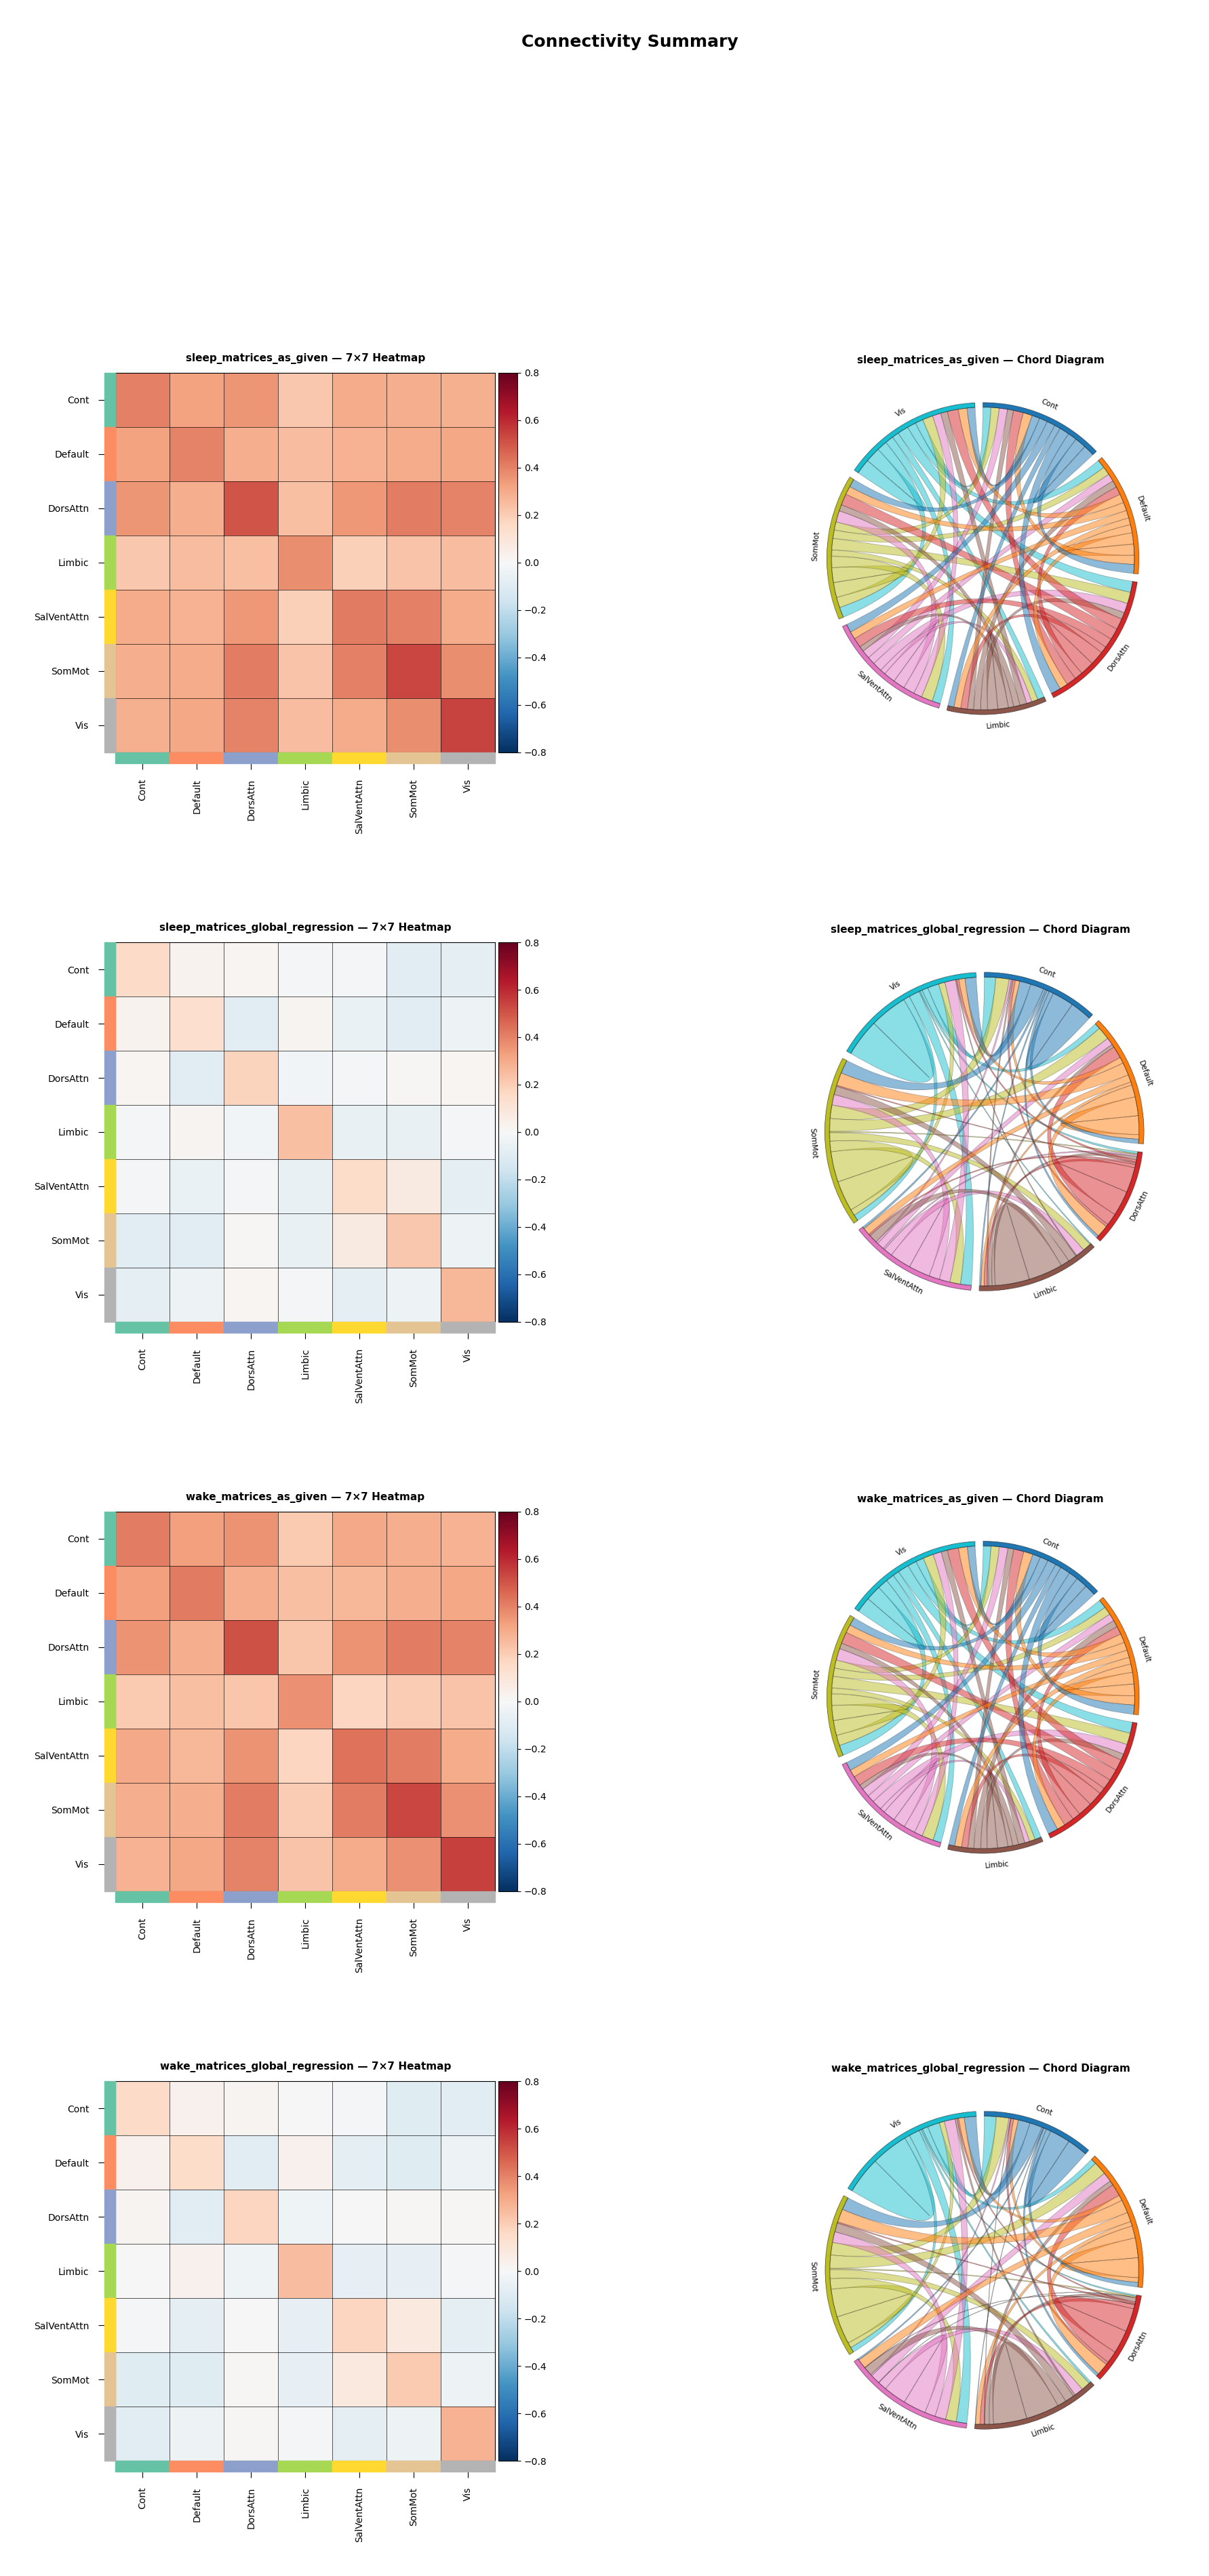

In [19]:
#combining into pdf
import matplotlib.gridspec as gridspec

n_rows = len(all_matrices)
fig_summary = plt.figure(figsize=(22, 10 * n_rows))
gs = gridspec.GridSpec(n_rows, 2, figure=fig_summary, hspace=0.5, wspace=0.35)

for row, (stem, mat) in enumerate(all_matrices.items()):
    vmin, vmax = _vrange(stem)
    network_df = build_network_matrix(mat)

    ax_heat  = fig_summary.add_subplot(gs[row, 0])
    ax_chord = fig_summary.add_subplot(gs[row, 1])

    plot_7x7_heatmap(network_df, ax_heat,
                     title=f"{stem} — 7×7 Heatmap", vmin=vmin, vmax=vmax)
    plot_chord_diagram(network_df, ax_chord,
                       title=f"{stem} — Chord Diagram",
                       tmp_png=f"_tmp_chord_{stem}.png")

fig_summary.suptitle("Connectivity Summary", fontsize=18, fontweight='bold', y=1.005)
plt.savefig("combined_connectivity_summary.pdf", dpi=150, bbox_inches="tight")
print("Saved: combined_connectivity_summary.pdf")
plt.show()


In [ ]:
# ── Per-subject 7×7 heatmap + chord diagram, one PDF per .npy file ──
for stem, stack in npy_data.items():
    n_subjects = stack.shape[0]
    fig, axes = plt.subplots(n_subjects, 2, figsize=(20, 9 * n_subjects))
    
    for i in range(n_subjects):
        network_df = build_network_matrix(stack[i])
        vmin, vmax = _vrange(stem)
        
        plot_7x7_heatmap(network_df, axes[i, 0],
                         title=f"Subject {i+1} — 7×7 Heatmap",
                         vmin=vmin, vmax=vmax)
        plot_chord_diagram(network_df, axes[i, 1],
                           title=f"Subject {i+1} — Chord Diagram",
                           tmp_png=f"_tmp_chord_{stem}_sub{i+1}.png")
    
    fig.suptitle(f"Per-Subject Connectivity — {stem}", fontsize=16, fontweight='bold', y=1.001)
    plt.tight_layout()
    out_pdf = f"subjects_7x7_{stem}.pdf"
    plt.savefig(out_pdf, dpi=80, bbox_inches="tight")
    print(f"Saved: {out_pdf}")
    plt.show()